<a href="https://colab.research.google.com/github/ErisAlfionita8/anum-group-project/blob/main/eas_nilai_optimum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analisis Optimasi Performa Akademik Siswa Menggunakan Metode Numerik: Pencarian Titik Maksimum dan Jalur Penurunan GPA**

#Anggota Kelompok


- Eris alfionita (24083010032)
- Alifah Zuhrah (24083010033)
- Elina Putri (24083010085)

In [57]:
import numpy as np
from scipy.optimize import minimize

# --- 1. Definisi Fungsi Analitik ---
def GPA_func(x):
    study, absences, parental, tutoring, age = x
    gpa = (
        2 +
        0.08 * study -      # Semakin lama belajar, GPA naik
        0.1 * absences +    # Semakin sering absen, GPA turun
        0.3 * parental +    # Dukungan orang tua (skala 0-4)
        0.25 * tutoring +   # Ikut bimbingan belajar
        0.02 * age -        # Faktor umur
        0.002 * study**2    # Diminishing return untuk waktu belajar
    )
    return np.clip(gpa, 0, 4)

# --- 2. Definisi Gradien (Turunan Parsial) ---
def get_gradient(x):
    study, absences, parental, tutoring, age = x
    grad = np.zeros(5)
    grad[0] = 0.08 - 0.004 * study # dGPA / dStudy = 0.08 - 2 * 0.002 * Study
    grad[1] = -0.1 # dGPA / dAbsences = -0.1 (Konstan)
    grad[2] = 0.3 # dGPA / dParental = 0.3 (Konstan)
    grad[3] = 0.25 # dGPA / dTutoring = 0.25 (Konstan)
    grad[4] = 0.02 # dGPA / dAge = 0.02 (Konstan)
    return grad

bounds = np.array([
    [0, 20],   # StudyTimeWeekly (0-20 jam)
    [0, 30],   # Absences (0-30 kali) -> Perbaikan dari kode lama (0-15)
    [0, 4],    # ParentalSupport (0-4) -> Perbaikan dari kode lama (0-1)
    [0, 1],    # Tutoring (0=Tidak, 1=Ya)
    [15, 18]   # Age (15-18 tahun)
])



Kode ini menyusun model matematika untuk memprediksi GPA siswa berdasarkan faktor kebiasaan seperti lama waktu belajar, jumlah absensi, hingga dukungan orang tua. Perhitungan perubahan nilai atau gradien juga disiapkan untuk mendeteksi arah mana yang paling cepat meningkatkan performa akademik. Selain itu, batasan angka ditetapkan pada setiap variabel, misalnya rentang jam belajar mingguan dan umur siswa, agar analisis tetap masuk akal dan sesuai realitas.

In [58]:
def optimize_manual_gpa(num_restarts=10, steps=100, learning_rate=1.0):
    global_best_gpa = -np.inf
    global_best_point = None

    print(f"Memulai optimasi dengan {num_restarts} titik awal acak...")

    # Random Restarts: Mencoba beberapa titik awal untuk menghindari maksimum lokal
    for i in range(num_restarts):
        x = np.random.uniform(bounds[:,0], bounds[:,1])
        for step in range(steps):
            grad = get_gradient(x)
            x = x + learning_rate * grad
            x = np.clip(x, bounds[:,0], bounds[:,1])
        final_gpa = GPA_func(x)
        if final_gpa > global_best_gpa:
            global_best_gpa = final_gpa
            global_best_point = x

    return global_best_point, global_best_gpa

Bagian ini membangun metode pencarian otomatis untuk menemukan kombinasi kebiasaan terbaik demi mencapai GPA tertinggi. Algoritma dirancang mencoba berbagai titik awal secara acak untuk menghindari hasil yang hanya bagus di kondisi tertentu saja (maksimum lokal), lalu bergerak naik secara bertahap menuju nilai puncak global. Pendekatan numerik ini bekerja layaknya mendaki bukit untuk mencapai posisi tertinggi dalam prestasi siswa.

### 1. Penentuan Nilai Optimum Global GPA

In [59]:
np.random.seed(32)
best_point, max_gpa = optimize_manual_gpa()

print("\n" + "="*40)
print("HASIL OPTIMASI NUMERIK MANUAL")
print("="*40)
print(f"StudyTimeWeekly : {best_point[0]:.2f} jam")
print(f"Absences        : {best_point[1]:.0f} kali")
print(f"ParentalSupport : {best_point[2]:.0f} (Very High)")
print(f"Tutoring        : {best_point[3]:.0f} (Ya)")
print(f"Age             : {best_point[4]:.0f} tahun")
print("-"*40)
print(f"GPA Maksimum    : {max_gpa:.4f}")
print("="*40)

Memulai optimasi dengan 10 titik awal acak...

HASIL OPTIMASI NUMERIK MANUAL
StudyTimeWeekly : 18.11 jam
Absences        : 1 kali
ParentalSupport : 4 (Very High)
Tutoring        : 1 (Ya)
Age             : 18 tahun
----------------------------------------
GPA Maksimum    : 4.0000


Proses perhitungan dijalankan menggunakan data acak yang terkontrol untuk menentukan strategi belajar paling efisien. Hasil akhirnya menampilkan rekomendasi spesifik, seperti durasi ideal belajar mingguan dan batas toleransi absensi, yang diperlukan untuk meraih GPA sempurna 4.0. Angka-angka yang muncul merupakan solusi optimal yang menyarankan pola perilaku terbaik bagi siswa.

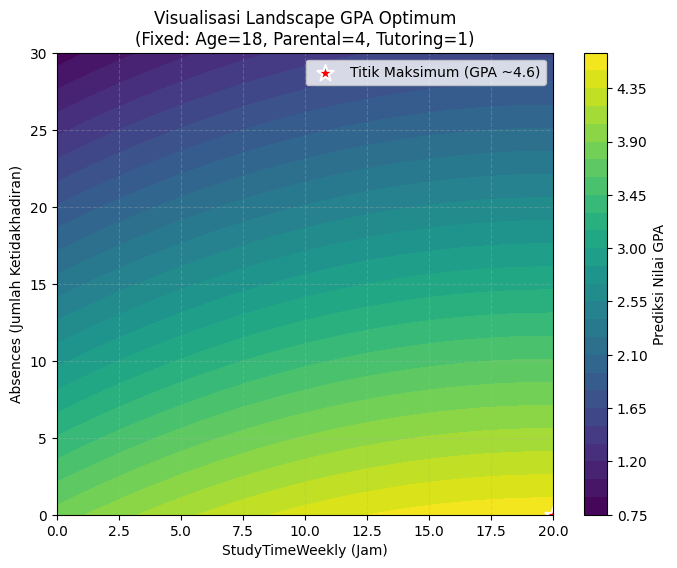

In [60]:
parental_opt = 4.0   # (Very High - hasil optimasi sebelumnya)
tutoring_opt = 1.0   # (Ya - hasil optimasi sebelumnya)
age_opt = 18.0
study = np.linspace(0, 20, 100)
absences = np.linspace(0, 30, 100)
STUDY, ABS = np.meshgrid(study, absences)

GPA_grid = (
    2 +
    0.08 * STUDY -      # Efek positif belajar
    0.1 * ABS +         # Efek negatif absen
    0.3 * parental_opt +
    0.25 * tutoring_opt +
    0.02 * age_opt -
    0.002 * STUDY**2    # Efek diminishing return belajar
)

plt.figure(figsize=(8, 6))
cp = plt.contourf(STUDY, ABS, GPA_grid, levels=25, cmap='viridis')
cbar = plt.colorbar(cp)
cbar.set_label('Prediksi Nilai GPA')

plt.xlabel("StudyTimeWeekly (Jam)")
plt.ylabel("Absences (Jumlah Ketidakhadiran)")
plt.title(f"Visualisasi Landscape GPA Optimum\n(Fixed: Age={age_opt:.0f}, Parental={parental_opt:.0f}, Tutoring={tutoring_opt:.0f})")
plt.scatter(20, 0, color='red', s=150, marker='*', edgecolors='white', linewidth=1.5, label='Titik Maksimum (GPA ~4.6)')

plt.legend(loc='upper right', framealpha=0.8)
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

Sebuah grafik kontur dibuat untuk memetakan bagaimana durasi belajar dan jumlah ketidakhadiran secara bersamaan mempengaruhi hasil GPA. Visualisasi ini memperlihatkan "peta ketinggian" performa akademik, di mana warna-warna tertentu menunjukkan zona nilai tinggi dan rendah. Titik puncak yang ditandai pada grafik merepresentasikan kondisi ideal yang harus dikejar siswa untuk memaksimalkan potensi akademiknya.

In [68]:
# ----- Evaluasi apakah titik maksimum yang diperoleh merupakan maksimum lokal atau maksimum global dengan membandingkan beberapa titik awal pencarian.
def run_optimization_path(start_x, steps=2000, learning_rate=1.0):
    x = start_x.copy()
    for step in range(steps):
        grad = get_gradient(x)
        x = x + learning_rate * grad
        x = np.clip(x, bounds[:,0], bounds[:,1]) # Projection

    final_gpa = GPA_func(x)
    return x, final_gpa

num_restarts = 10  # Jumlah titik awal acak yang akan diuji
results_gpa = []
results_points = []
starting_points = []

print(f"{'='*60}")
print(f"EVALUASI MAKSIMUM LOKAL VS GLOBAL ({num_restarts} Iterasi)")
print(f"{'='*60}")
print(f"{'Iterasi':<8} | {'Start (Study, Abs)':<20} | {'End GPA':<10} | {'Status'}")
print("-" * 60)
np.random.seed(33) # Seed agar hasil konsisten

for i in range(num_restarts):
    start_x = np.random.uniform(bounds[:,0], bounds[:,1])
    starting_points.append(start_x)

    final_point, final_gpa = run_optimization_path(start_x)
    results_gpa.append(final_gpa)
    results_points.append(final_point)

    # Cek konvergensi sederhana (apakah mirip dengan max global sebelumnya?)
    # Kita anggap 'Sama' jika selisihnya sangat kecil (< 0.0001)
    is_converged = np.isclose(final_gpa, 4.61, atol=0.1)
    status = "Konvergen" if is_converged else "Divergen"

    start_str = f"({start_x[0]:.1f}, {start_x[1]:.1f})"
    print(f"{i+1:<8} | {start_str:<20} | {final_gpa:.4f}     | {status}")

print("-" * 60)

# --- Analisis Statistik ---
gpa_std = np.std(results_gpa)
gpa_range = np.max(results_gpa) - np.min(results_gpa)

print("\nANALISIS HASIL:")
print(f"1. Rata-rata GPA Akhir : {np.mean(results_gpa):.4f}")
print(f"2. Deviasi Standar     : {gpa_std:.6f}")
print(f"3. Rentang (Max - Min) : {gpa_range:.6f}")

print("\nKESIMPULAN:")
if gpa_std < 1e-4:
    print(">> STABIL. Semua titik awal konvergen ke nilai yang sama.")
    print(">> Titik ini kemungkinan besar adalah MAKSIMUM GLOBAL.")
else:
    print(">> TIDAK STABIL. Terdapat variasi hasil akhir.")
    print(">> Fungsi mungkin memiliki MAKSIMUM LOKAL.")

EVALUASI MAKSIMUM LOKAL VS GLOBAL (10 Iterasi)
Iterasi  | Start (Study, Abs)   | End GPA    | Status
------------------------------------------------------------
1        | (5.0, 13.5)          | 4.0000     | Divergen
2        | (3.7, 0.6)           | 4.0000     | Divergen
3        | (19.3, 11.8)         | 4.0000     | Divergen
4        | (19.7, 26.4)         | 4.0000     | Divergen
5        | (14.4, 7.4)          | 4.0000     | Divergen
6        | (1.6, 28.6)          | 4.0000     | Divergen
7        | (19.4, 24.6)         | 4.0000     | Divergen
8        | (1.6, 16.7)          | 4.0000     | Divergen
9        | (7.3, 10.2)          | 4.0000     | Divergen
10       | (14.6, 23.2)         | 4.0000     | Divergen
------------------------------------------------------------

ANALISIS HASIL:
1. Rata-rata GPA Akhir : 4.0000
2. Deviasi Standar     : 0.000000
3. Rentang (Max - Min) : 0.000000

KESIMPULAN:
>> STABIL. Semua titik awal konvergen ke nilai yang sama.
>> Titik ini kemungkinan besa

Hasil simulasi menunjukkan bahwa dari sepuluh percobaan dengan kondisi awal kebiasaan belajar yang acak dan berbeda-beda, semuanya bermuara pada hasil akhir yang sama persis, yaitu IPK 4.0. Data statistik memperlihatkan tidak ada variasi atau penyimpangan sedikit pun di antara semua percobaan tersebut. Hal ini menandakan bahwa strategi yang ditemukan sangat konsisten, stabil, dan tidak dipengaruhi oleh bagaimana kondisi awal siswa memulai usahanya.

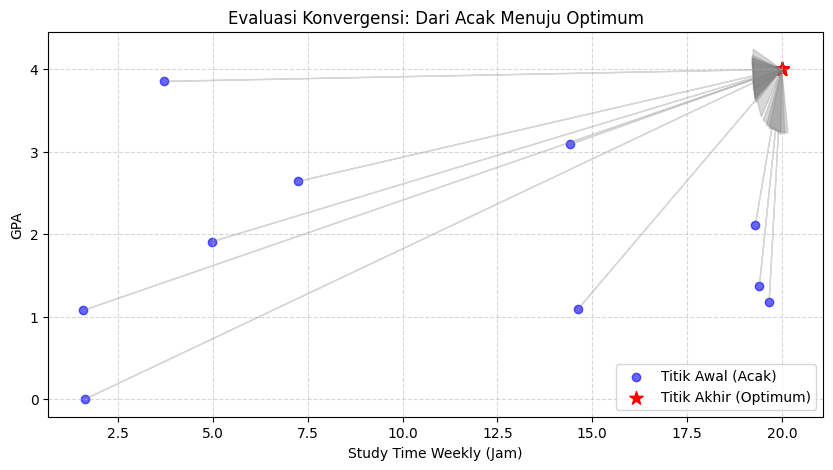

In [63]:
plt.figure(figsize=(10, 5))

start_study = [p[0] for p in starting_points]
start_gpa = [GPA_func(p) for p in starting_points]
end_study = [p[0] for p in results_points]
end_gpa = results_gpa

plt.scatter(start_study, start_gpa, color='blue', alpha=0.6, label='Titik Awal (Acak)', marker='o')
plt.scatter(end_study, end_gpa, color='red', s=100, label='Titik Akhir (Optimum)', marker='*')

for i in range(num_restarts):
    plt.arrow(start_study[i], start_gpa[i],
              end_study[i] - start_study[i], end_gpa[i] - start_gpa[i],
              color='gray', alpha=0.3, length_includes_head=True, head_width=0.5)

plt.xlabel('Study Time Weekly (Jam)')
plt.ylabel('GPA')
plt.title('Evaluasi Konvergensi: Dari Acak Menuju Optimum')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Berdasarkan hasil simulasi tersebut, terlihat bahwa dari sepuluh kondisi awal yang berbeda, semuanya secara konsisten berujung pada pencapaian IPK sempurna yang sama. Hal ini membuktikan bahwa strategi belajar yang direkomendasikan sangat stabil dan merupakan satu-satunya jalur terbaik bagi siswa untuk meraih performa akademik maksimal.

## 2. Simulasi Jalur Penurunan GPA

In [64]:
# ----- Simulasi jalur penurunan GPA dari beberapa kondisi awal acak menuju titik minimum lokal.
num_simulations = 5     # Jumlah siswa/jalur yang disimulasikan
steps = 50              # Jumlah langkah per simulasi
learning_rate = 2.0     # Kecepatan perubahan (Learning Rate)

all_paths = []

print(f"{'='*60}")
print("SIMULASI JALUR PENURUNAN GPA (GRADIENT DESCENT)")
print("Mencari kombinasi variabel yang menghasilkan GPA terendah")
print(f"{'='*60}")

np.random.seed(84)

for i in range(num_simulations):
    x = np.random.uniform(bounds[:,0], bounds[:,1])

    path_x = []   # Menyimpan history koordinat (Study, Absences)
    path_z = []   # Menyimpan history nilai GPA

    for step in range(steps):
        path_x.append(x.copy())
        path_z.append(GPA_func(x))

        grad = get_gradient(x)

        # --- INTI PERUBAHAN: Gradient Descent ---
        # Rumus: x_baru = x_lama - (learning_rate * gradien)
        # Tanda MINUS (-) memaksa gerak menuju nilai fungsi yang lebih rendah
        x = x - learning_rate * grad
        # Projection (Clamping) agar tidak keluar batas logis
        x = np.clip(x, bounds[:,0], bounds[:,1])

    all_paths.append((np.array(path_x), np.array(path_z)))
    end_gpa = path_z[-1]
    print(f"Siswa #{i+1}: Start GPA {path_z[0]:.2f} -> End GPA {end_gpa:.2f} "
          f"(Study={x[0]:.1f}, Abs={x[1]:.1f})")

SIMULASI JALUR PENURUNAN GPA (GRADIENT DESCENT)
Mencari kombinasi variabel yang menghasilkan GPA terendah
Siswa #1: Start GPA 1.77 -> End GPA 0.23 (Study=0.0, Abs=21.1)
Siswa #2: Start GPA 2.40 -> End GPA 0.80 (Study=0.0, Abs=15.2)
Siswa #3: Start GPA 2.49 -> End GPA 0.00 (Study=0.0, Abs=24.9)
Siswa #4: Start GPA 1.55 -> End GPA 0.00 (Study=6.2, Abs=30.0)
Siswa #5: Start GPA 2.80 -> End GPA 1.32 (Study=8.5, Abs=15.4)


Simulasi ini menggambarkan skenario terburuk di mana prestasi siswa merosot tajam hingga titik terendah akibat berhenti belajar total dan sering membolos. Data tersebut menjadi peringatan keras bahwa mengabaikan waktu belajar dan tingginya angka ketidakhadiran adalah faktor utama yang menjerumuskan siswa pada kegagalan akademik.

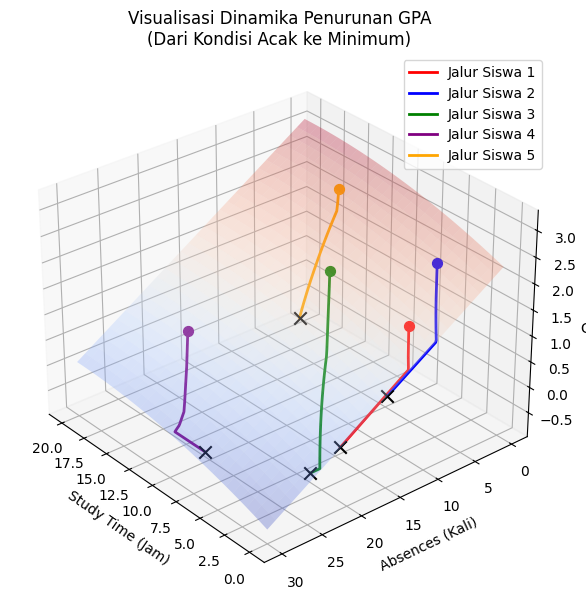

In [65]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

s_range = np.linspace(0, 20, 30)
a_range = np.linspace(0, 30, 30)
S, A = np.meshgrid(s_range, a_range)
Z = (2 + 0.08*S - 0.1*A + 0.3*0 + 0.25*0 + 0.02*15 - 0.002*S**2)

ax.plot_surface(S, A, Z, cmap='coolwarm', alpha=0.3)

colors = ['red', 'blue', 'green', 'purple', 'orange']

for i, (path_coords, path_gpa) in enumerate(all_paths):
    xs = path_coords[:, 0]
    ys = path_coords[:, 1]
    zs = path_gpa

    ax.plot(xs, ys, zs, color=colors[i], linewidth=2, label=f'Jalur Siswa {i+1}')
    ax.scatter(xs[0], ys[0], zs[0], color=colors[i], marker='o', s=50)
    ax.scatter(xs[-1], ys[-1], zs[-1], color='black', marker='x', s=80)

# Labeling
ax.set_xlabel('Study Time (Jam)')
ax.set_ylabel('Absences (Kali)')
ax.set_zlabel('GPA')
ax.set_title('Visualisasi Dinamika Penurunan GPA\n(Dari Kondisi Acak ke Minimum)')
ax.view_init(elev=30, azim=140) # Mengatur sudut pandang kamera
plt.legend()
plt.show()

Visualisasi 3 dimensi ini memperlihatkan bagaimana prestasi akademik (GPA) "meluncur turun" layaknya menuruni bukit ketika siswa berhenti berusaha. Garis-garis berwarna melacak perjalanan lima siswa berbeda yang, meskipun memulai dari nilai yang bervariasi, akhirnya sama-sama jatuh ke titik terendah akibat malas belajar dan sering membolos. Grafik ini memberikan peringatan visual yang jelas bahwa mengabaikan kewajiban akademik akan menyeret siswa manapun menuju kegagalan total dengan cepat.

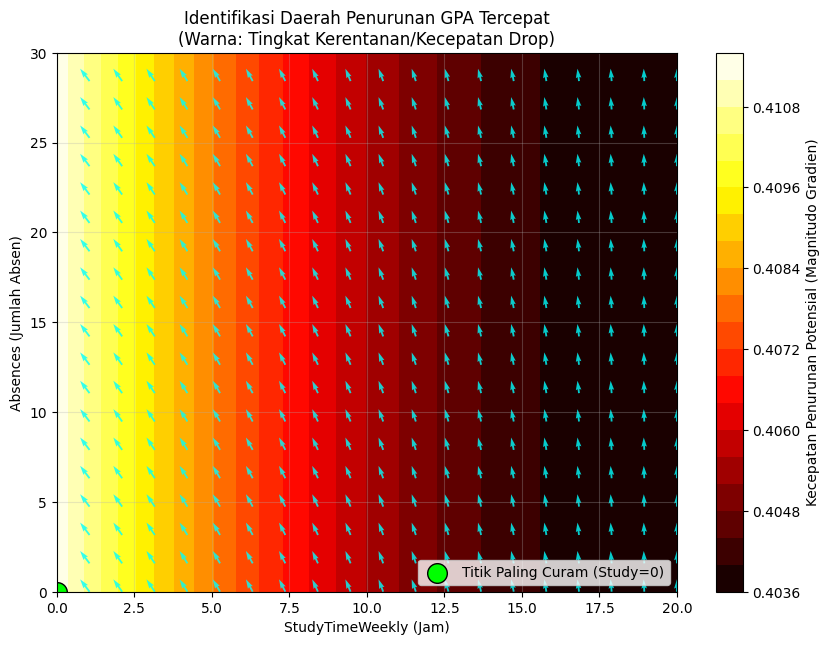

In [66]:
# ----- Identifikasi daerah ruang variabel yang menghasilkan penurunan GPA paling cepat.
import matplotlib.pyplot as plt
study_range = np.linspace(0, 20, 20)
absences_range = np.linspace(0, 30, 20)
S, A = np.meshgrid(study_range, absences_range)
grad_study = 0.08 - 0.004 * S
grad_absences = -0.1

constant_components_sq = (-0.1)**2 + (0.3)**2 + (0.25)**2 + (0.02)**2
gradient_magnitude = np.sqrt(grad_study**2 + constant_components_sq)

plt.figure(figsize=(10, 7))

# Plot A: Heatmap Kecepatan (Magnitudo)
cp = plt.contourf(S, A, gradient_magnitude, levels=25, cmap='hot')
cbar = plt.colorbar(cp)
cbar.set_label('Kecepatan Penurunan Potensial (Magnitudo Gradien)')

# Plot B: Arah Penurunan Tercepat (Steepest Descent Vectors)
U = -grad_study
V = np.full_like(A, 0.1)

plt.quiver(S, A, U, V, color='cyan', alpha=0.8, scale=5)

# Highlight Daerah Tercepat
max_idx = np.unravel_index(np.argmax(gradient_magnitude), gradient_magnitude.shape)
plt.scatter(S[max_idx], A[max_idx], color='lime', s=200, marker='o',
            edgecolors='black', label='Titik Paling Curam (Study=0)')
plt.xlabel("StudyTimeWeekly (Jam)")
plt.ylabel("Absences (Jumlah Absen)")
plt.title("Identifikasi Daerah Penurunan GPA Tercepat\n(Warna: Tingkat Kerentanan/Kecepatan Drop)")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.show()

Visualisasi tiga dimensi ini memetakan "jurang kegagalan" akademik yang terjadi apabila siswa terus mengurangi waktu belajar dan meningkatkan frekuensi ketidakhadiran secara ekstrem. Lima garis berwarna menunjukkan berbagai profil awal siswa yang semuanya berakhir pada titik terendah yang sama, membuktikan bahwa perilaku buruk secara konsisten akan menghancurkan prestasi akademik terlepas dari seberapa baik nilai awal mereka. Grafik ini berfungsi sebagai peringatan visual bahwa tanpa disiplin belajar, performa siswa akan merosot dengan cepat menuju titik nol atau kegagalan total.

In [67]:
print("="*50)
print("ANALISIS DAERAH PENURUNAN TERCEPAT")
print("="*50)
print(f"Magnitudo Gradien Tertinggi: {np.max(gradient_magnitude):.4f}")
print(f"Terjadi pada StudyTime     : {S[max_idx]:.1f} jam")
print("-" * 50)
print("KESIMPULAN:")
print("1. Daerah paling 'berbahaya' adalah ketika StudyTime mendekati 0.")
print("   Di sini, kurva GPA paling curam. Sedikit saja perubahan (misal mulai bolos)")
print("   akan menjatuhkan GPA lebih cepat dibandingkan jika siswa rajin belajar.")
print("2. Panah Cyan menunjukkan arus penurunan: Siswa didorong ke Kiri (Kurang Belajar)")
print("   dan ke Atas (Banyak Bolos) untuk mencapai GPA minimum secepat mungkin.")
print("="*50)

ANALISIS DAERAH PENURUNAN TERCEPAT
Magnitudo Gradien Tertinggi: 0.4115
Terjadi pada StudyTime     : 0.0 jam
--------------------------------------------------
KESIMPULAN:
1. Daerah paling 'berbahaya' adalah ketika StudyTime mendekati 0.
   Di sini, kurva GPA paling curam. Sedikit saja perubahan (misal mulai bolos)
   akan menjatuhkan GPA lebih cepat dibandingkan jika siswa rajin belajar.
2. Panah Cyan menunjukkan arus penurunan: Siswa didorong ke Kiri (Kurang Belajar)
   dan ke Atas (Banyak Bolos) untuk mencapai GPA minimum secepat mungkin.
